
--- Iteration: 1 ---
RMP solved. Current roll count (LP bound): 87.75247524752474
Dual prices: [0.4257, 0.3168, 0.2, 0.1584, 0.0495]
Subproblem solved. Max value = 1.0495, Reduced Cost = -0.0495
Found new profitable pattern: [0, 3, 0, 0, 2]

--- Iteration: 2 ---
RMP solved. Current roll count (LP bound): 87.48275862068967
Dual prices: [0.4384, 0.3005, 0.2, 0.1626, 0.0493]
Subproblem solved. Max value = 1.0739, Reduced Cost = -0.0739
Found new profitable pattern: [0, 0, 0, 6, 2]

--- Iteration: 3 ---
RMP solved. Current roll count (LP bound): 86.9
Dual prices: [0.45, 0.3, 0.2, 0.15, 0.05]
Subproblem solved. Max value = 1.0, Reduced Cost = 0.0

--- Column Generation Complete ---
No more profitable patterns found. Optimal LP solution reached.

--- Solving Final Integer Problem ---
Total stock rolls used: 87

Unique cutting patterns found:
Pattern          | Total
-------------------------
[1, 1, 0, 1, 2]  | 60   
[0, 3, 0, 0, 2]  | 9    
[0, 0, 0, 6, 2]  | 8    
[0, 0, 5, 0, 0]  | 7    


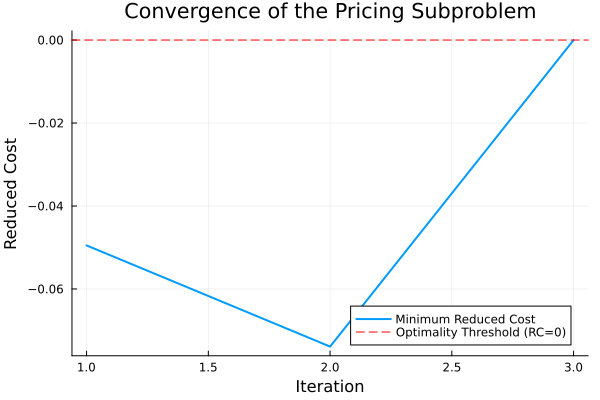

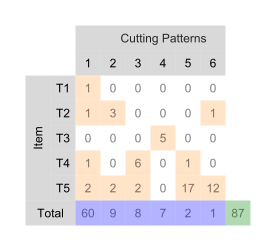

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 6 – Graph problems
#  Section: 6.2.2 - Column generation for the one-dimensional cutting stock problem
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP       # Modeling language
using HiGHS      # Solver
using DataFrames # For data handling
using Random     # For random number generation
using Plots      # For plotting

# Include utility functions for drawing solutions
include("utils/1dcut_utils.jl")

# Function to plot the convergence of reduced costs
function plot_reduced_costs(reduced_cost_history)
    p = Plots.plot(
        1:length(reduced_cost_history), 
        reduced_cost_history,
        label="Minimum Reduced Cost",
        xlabel="Iteration",
        ylabel="Reduced Cost",
        title="Convergence of the Pricing Subproblem",
        legend=:bottomright,
        linewidth=2
    )
    # Add a horizontal line at y=0 to show the convergence target
    Plots.hline!(p, [0], linestyle=:dash, color=:red, label="Optimality Threshold (RC=0)")
    # Display the plot
    display(p)
end

# Function to create initial cutting patterns (columns)
function create_initial_columns(items, L, initial_columns_total)

    # Number of items
    n = length(items.Length)

    # Calculate the maximum number of each item that can fit in a panel
    max_item_limit = floor.(Int, L ./ items.Length)

    # Initialize the columns matrix
    columns = zeros(Int, (n + initial_columns_total, n))

    # Generate basic columns
    for i in 1:n
        # Set the quantity of item i to the maximum that fits in the panel
        columns[i, i] = max_item_limit[i]
    end

    # Initial item order
    item_order = collect(1:n)

    # Loop to generate random initial columns
    for id in n+1:initial_columns_total
        
        # Shuffle the order of items for diversity
        shuffle!(item_order)
        
        # Initialize the current length of the column
        current_length = 0

        # Randomly select how many of each item to include in the column
        # Ensure the total length does not exceed L
        for item in item_order
            # Randomly determine the quantity of the item to add
            # We check against remaining length to make a better pattern
            remaining_length = L - current_length
            item_length = items.Length[item]
            
            if item_length > 0 # Avoid division by zero
                 # Max possible of this item in the remaining space
                possible_qty = floor(Int, remaining_length / item_length)
                
                if possible_qty > 0
                    qty = rand(0:possible_qty)
                    # Calculate the length added by this item
                    added_length = qty * item_length
                    
                    # Store the quantity in the columns matrix
                    columns[id, item] = qty
                    # Update the current length
                    current_length += added_length
                end
            end
        end
    end

    # Ensure the columns are unique
    columns = unique(columns, dims=1)

    return columns
end

# Function to solve the master problem (RMP)
function master_problem(items, patterns; solve_as_integer=false)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    
    # Number of patterns and items
    num_items = size(items,1)
    num_patterns = size(patterns,1)

    # Create the decision variables
    # y[i] = number of times to use pattern i
    # We can choose to solve as integer or continuous based on the flag
    if solve_as_integer 
        @variable(model, y[1:num_patterns] >= 0, Int)
    else
        @variable(model, y[1:num_patterns] >= 0)
    end

    # Objective: Minimize the total number of stock rolls used
    @objective(model, Min, sum(y))

    # Constraints: For each item j, produce at least the required demand
    @constraint(model, demand_con[j = 1:num_items], 
                       sum(patterns[i,j] * y[i] for i in 1:num_patterns) >= items.Demand[j])
    
    # Solve the model
    JuMP.optimize!(model)
    
    # Check the termination status
    if solve_as_integer
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            return nothing, Int(round(JuMP.objective_value(model))), JuMP.value.(y)
        else
            @warn("Final integer problem did not solve to optimality. Status: $(JuMP.termination_status(model))")
            return nothing, nothing, nothing
        end 
    else
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            # If the model is solved to optimality, extract the dual prices
            # from the demand constraints. These will be used in the subproblem.
            dual_prices = JuMP.dual.(demand_con)
            println("RMP solved. Current roll count (LP bound): $(JuMP.objective_value(model))")
            println("Dual prices: $(round.(dual_prices; digits=4))") # Optional: can be noisy
            return dual_prices, nothing, nothing
        else
            error("RMP was not solved to optimality. Status: $(JuMP.termination_status(model))")
        end
    end
end

# Function to solve the pricing subproblem (knapsack problem)
function subproblem(items, L, dual_prices)
    # Number of items
    num_items = size(items, 1)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Create the decision variables
    # x[i] = number of items of type i in the new pattern
    @variable(model, x[1:num_items] >= 0, Int)

    # Objective: Maximize the total "value" of the pattern
    @objective(model, Max, sum(dual_prices[i] * x[i] for i in 1:num_items))
    
    # Constraint: The total length of items in the pattern cannot exceed the stock length
    @constraint(model, sum(items.Length[i] * x[i] for i in 1:num_items) <= L)
    
    # Solve the model
    JuMP.optimize!(model)

    # Check the termination status
    if termination_status(model) != JuMP.OPTIMAL
        error("Pricing subproblem was not solved to optimality. Status: $(termination_status(model))")
    end

    # If the model is solved to optimality, we can extract the maximum value
    max_knapsack_value = JuMP.objective_value(model)

    # Calculate the reduced cost
    reduced_cost = 1 - max_knapsack_value

    # Log the results
    println("Subproblem solved. Max value = $(round(max_knapsack_value; digits=4)), Reduced Cost = $(round(reduced_cost; digits=4))")
    
    # Check if the reduced cost indicates a profitable pattern
    # We use a small tolerance to avoid numerical issues
    TOLERANCE = -1e-6
    if reduced_cost < TOLERANCE
        # A profitable pattern was found, return it
        new_pattern = round.(Int, JuMP.value.(x))
        println("Found new profitable pattern: $(new_pattern)")
        return new_pattern, reduced_cost
    else
        # No profitable pattern was found, signal to stop
        return nothing, reduced_cost
    end
end

# Function to display the final solution
function display_solution(items, patterns, x_solution)
    
    # Extract the amount cutting patterns
    pattern_ids = findall(x -> x > 0, x_solution)
    unique_patterns_total = Dict{Vector{Int}, Int}()
    for id in pattern_ids
        pattern = patterns[id, :]
        if haskey(unique_patterns_total, pattern)
            unique_patterns_total[pattern] += trunc(Int, x_solution[id])
        else
            unique_patterns_total[pattern] = trunc(Int, x_solution[id])
        end
    end

    # Sort the unique patterns by their counts in descending order
    unique_patterns_total = sort(collect(unique_patterns_total), by = x -> x[2], rev=true)

    # Print the unique patterns and their counts
    println("\nUnique cutting patterns found:")
    println("Pattern          | Total")
    println("-------------------------")
    item_produced = zeros(Int, size(items, 1))
    for (pattern, count) in unique_patterns_total
        items_pattern = (pattern .* count)
        item_produced = item_produced + items_pattern
        pattern = rpad(pattern, 16)
        count = rpad(count, 5)
        println("$(pattern) | $count")
    end

    # Print the production summary
    println("\nProduction summary:")
    println("Item Type | Item Length | Demand | Produced | Overproduction")
    println("------------------------------------------------------------")
    for i in 1:size(items, 1)
        item = rpad("T$(i)", 9)
        length = rpad(items.Length[i], 11)
        demand = rpad(items.Demand[i], 6)
        produced = rpad(item_produced[i], 8)
        over = item_produced[i] - items.Demand[i]
        println("$(item) | $(length) | $(demand) | $(produced) | $(over)")
    end

    # Draw the cutting patterns produced
    plot_solution(items, unique_patterns_total)
end

# Main function to execute the column generation process for the 1D cutting stock problem
function solve_1dcut_gc(items, L, initial_columns_total, iterations)
    
    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # --- 1. Create initial patterns ---
    patterns = create_initial_columns(items, L, initial_columns_total)
    
    # --- 2. Column generation loop ---
    for iteration in 1:iterations
        println("\n--- Iteration: $iteration ---")
        
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        dual_prices, _, _ = master_problem(items, patterns, solve_as_integer = false)
        
        # --- 4. Solve the Pricing Subproblem ---
        new_pattern, reduced_cost = subproblem(items, L, dual_prices)

        # Store the reduced cost history
        push!(reduced_cost_history, reduced_cost)

        # --- 5. Check if a new pattern was found ---
        if isnothing(new_pattern)
            println("\n--- Column Generation Complete ---")
            println("No more profitable patterns found. Optimal LP solution reached.")
            break
        else
            # A new pattern was found, add it to our matrix for the next iteration
            patterns = vcat(patterns, new_pattern')
            # Optional: Keep the pattern matrix lean by removing duplicates
            patterns = unique(patterns, dims=1)
        end
    end

    # --- 6. Solve the Final Integer Problem ---
    println("\n--- Solving Final Integer Problem ---")
    _, total_rolls_used, y_solution = master_problem(items, patterns, solve_as_integer = true)    

    if isnothing(total_rolls_used)
        println("Could not find a final integer solution.")
        return
    end
 
    # --- 7. Generate reduced cost Plot ---
    plot_reduced_costs(reduced_cost_history)

    # Display the final solution
    println("Total stock rolls used: $total_rolls_used")
    display_solution(items, patterns, y_solution)
end

# Set the random seed for reproducibility
Random.seed!(1)

# Load the data (Length and Demand)
L = 100 # Length of each panel
items = DataFrame(
    "Length" => [45, 30, 20, 15, 5],
    "Demand" => [60, 88, 35, 110, 200]
)

# Define parameters for the column generation process
iterations = 100            # Max number of iterations for column generation
initial_columns_total = 20  # Initial number of random columns to generate

# Execute the column generation process
solve_1dcut_gc(items, L, initial_columns_total, iterations)